In [1]:
import numpy as np
import pandas as pd
import mne
from scipy import signal, stats
from scipy.signal import welch, hilbert
from itertools import combinations

In [2]:
raw = mne.io.read_raw_eeglab(
    "../data/sub-03_task-ImaginedEmotion_eeg.set",
    preload=True
)
events, event_id = mne.events_from_annotations(raw)

print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'])
print("Event types:", event_id)

sfreq = raw.info['sfreq']
ch_names = raw.ch_names

#Filtering the response
raw.filter(1.0, 45.0, fir_window='hamming')
raw.notch_filter(freqs=60)


tmin, tmax = 0.0, 4.0 #Four second increments

epochs = mne.Epochs(
    raw, events,
    event_id=event_id,
    tmin=tmin, tmax=tmax,
    baseline=None,
    preload=True,
    reject_by_annotation=True
)


Reading /Users/jranji/Desktop/ML Project/Code/Part 2/../data/sub-03_task-ImaginedEmotion_eeg.fdt
Reading 0 ... 1251327  =      0.000 ...  4887.996 secs...
Used Annotations descriptions: [np.str_('ExitThankYou'), np.str_('FeelingItInstructionsButton'), np.str_('ImaginationSuggestions'), np.str_('InstructionsForEnding'), np.str_('anger'), np.str_('awe'), np.str_('compassion'), np.str_('content'), np.str_('disgust'), np.str_('enter'), np.str_('excite'), np.str_('exit'), np.str_('fear'), np.str_('frustration'), np.str_('grief'), np.str_('happy'), np.str_('jealousy'), np.str_('joy'), np.str_('love'), np.str_('postbase'), np.str_('postbase_instruct'), np.str_('prebase'), np.str_('prebase_instruct'), np.str_('press'), np.str_('press1'), np.str_('relax'), np.str_('relief'), np.str_('sad')]
Channels: ['A4', 'A5', 'A6', 'A7', 'A12', 'A13', 'A14', 'A18', 'A19', 'A20', 'A21', 'A30', 'A31', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'B14', 'B16', 'B17', 'B18',

In [4]:
print(f"\nEpochs shape: {epochs.get_data().shape}")  # (n_epochs, n_channels, n_times)

data = epochs.get_data()          # shape: (n_epochs, n_channels, n_times)
labels = epochs.events[:, 2]     # integer event codes per epoch
n_epochs, n_channels, n_times = data.shape



Epochs shape: (94, 134, 1025)


In [5]:
# ── 4. FEATURE EXTRACTION HELPERS ────────────────────────────────────────────

BANDS = {
    'delta': (0.5, 4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

def band_power(signal_1d, sfreq, fmin, fmax):
    """Compute average power in a frequency band using Welch's method."""
    freqs, psd = welch(signal_1d, sfreq, nperseg=min(256, len(signal_1d)))
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapezoid(psd[idx], freqs[idx])

def hjorth_params(signal_1d):
    """Activity, Mobility, Complexity."""
    activity   = np.var(signal_1d)
    d1         = np.diff(signal_1d)
    d2         = np.diff(d1)
    mobility   = np.sqrt(np.var(d1) / (activity + 1e-10))
    complexity = np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mobility + 1e-10)
    return activity, mobility, complexity

def spectral_entropy(signal_1d, sfreq):
    """Normalized Shannon entropy of the power spectrum."""
    _, psd = welch(signal_1d, sfreq, nperseg=min(256, len(signal_1d)))
    psd_norm = psd / (psd.sum() + 1e-10)
    return -np.sum(psd_norm * np.log2(psd_norm + 1e-10))

def zero_crossing_rate(signal_1d):
    return ((signal_1d[:-1] * signal_1d[1:]) < 0).sum() / len(signal_1d)

def channel_correlation(epoch_data):
    """
    Upper-triangle pairwise Pearson correlations between all channel pairs.
    Returns a flat vector of length n_channels*(n_channels-1)/2.
    """
    corr_matrix = np.corrcoef(epoch_data)   # (n_channels, n_channels)
    idx = np.triu_indices(n_channels, k=1)
    return corr_matrix[idx]

def frontal_alpha_asymmetry(epoch_data, ch_names):
    """
    Right-minus-left frontal alpha power asymmetry.
    Requires F3/F4 or similar left/right frontal pairs to be present.
    Adjust channel names to match your montage.
    """
    left_frontal  = ['F3', 'F7', 'AF3']
    right_frontal = ['F4', 'F8', 'AF4']

    left_chs  = [ch for ch in left_frontal  if ch in ch_names]
    right_chs = [ch for ch in right_frontal if ch in ch_names]

    if not left_chs or not right_chs:
        return np.nan

    li = [ch_names.index(c) for c in left_chs]
    ri = [ch_names.index(c) for c in right_chs]

    left_alpha  = np.mean([band_power(epoch_data[i], sfreq, 8, 13) for i in li])
    right_alpha = np.mean([band_power(epoch_data[i], sfreq, 8, 13) for i in ri])

    # Log-transform is standard for alpha asymmetry
    return np.log(right_alpha + 1e-10) - np.log(left_alpha + 1e-10)



In [6]:
# ── 5. MAIN EXTRACTION LOOP ──────────────────────────────────────────────────

all_features = []

for ep_idx in range(n_epochs):
    epoch = data[ep_idx]   # (n_channels, n_times)
    feat  = {}

    for ch_idx, ch_name in enumerate(ch_names):
        sig = epoch[ch_idx]

        # -- Time-domain --
        feat[f'{ch_name}_mean']     = np.mean(sig)
        feat[f'{ch_name}_var']      = np.var(sig)
        feat[f'{ch_name}_skew']     = stats.skew(sig)
        feat[f'{ch_name}_kurt']     = stats.kurtosis(sig)
        feat[f'{ch_name}_zcr']      = zero_crossing_rate(sig)
        feat[f'{ch_name}_p2p']      = np.ptp(sig)

        act, mob, comp = hjorth_params(sig)
        feat[f'{ch_name}_hjorth_act']  = act
        feat[f'{ch_name}_hjorth_mob']  = mob
        feat[f'{ch_name}_hjorth_cmp']  = comp

        # -- Frequency-domain: band power --
        bp = {}
        for band, (fmin, fmax) in BANDS.items():
            bp_val = band_power(sig, sfreq, fmin, fmax)
            feat[f'{ch_name}_bp_{band}'] = bp_val
            bp[band] = bp_val

        # -- Band power ratios (robust relative features) --
        total_bp = sum(bp.values()) + 1e-10
        for band in BANDS:
            feat[f'{ch_name}_bpr_{band}'] = bp[band] / total_bp

        feat[f'{ch_name}_ratio_theta_alpha'] = bp['theta'] / (bp['alpha'] + 1e-10)
        feat[f'{ch_name}_ratio_alpha_beta']  = bp['alpha'] / (bp['beta']  + 1e-10)

        # -- Spectral entropy --
        feat[f'{ch_name}_spec_entropy'] = spectral_entropy(sig, sfreq)

    # -- Connectivity: pairwise channel correlations --
    corr_vals = channel_correlation(epoch)
    pairs = list(combinations(range(n_channels), 2))
    for (i, j), val in zip(pairs, corr_vals):
        feat[f'corr_{ch_names[i]}_{ch_names[j]}'] = val

    # -- Frontal alpha asymmetry --
    feat['frontal_alpha_asymmetry'] = frontal_alpha_asymmetry(epoch, ch_names)

    # -- Label --
    feat['event_code'] = labels[ep_idx]

    all_features.append(feat)
    if ep_idx % 10 == 0:
        print(f"  Processed epoch {ep_idx+1}/{n_epochs}")



  Processed epoch 1/94
  Processed epoch 11/94
  Processed epoch 21/94
  Processed epoch 31/94
  Processed epoch 41/94
  Processed epoch 51/94
  Processed epoch 61/94
  Processed epoch 71/94
  Processed epoch 81/94
  Processed epoch 91/94


In [10]:
df = pd.DataFrame(all_features)
print(df.shape)

(94, 11861)


In [43]:
df.columns[:26]

Index(['A4_mean', 'A4_var', 'A4_skew', 'A4_kurt', 'A4_zcr', 'A4_p2p',
       'A4_hjorth_act', 'A4_hjorth_mob', 'A4_hjorth_cmp', 'A4_bp_delta',
       'A4_bp_theta', 'A4_bp_alpha', 'A4_bp_beta', 'A4_bp_gamma',
       'A4_bpr_delta', 'A4_bpr_theta', 'A4_bpr_alpha', 'A4_bpr_beta',
       'A4_bpr_gamma', 'A4_ratio_theta_alpha', 'A4_ratio_alpha_beta',
       'A4_spec_entropy', 'A5_mean', 'A5_var', 'A5_skew', 'A5_kurt'],
      dtype='object')

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#PCA PART

#N_components = 2
scaler = StandardScaler()
pca_2 = PCA(n_components=2)
#N_components = 3
pca_3 = PCA(n_components=3)

scaled_df = scaler.fit_transform(df)

pca_vals_2 = pca_2.fit_transform(scaled_df)
pca_vals_3 = pca_3.fit_transform(scaled_df)

In [25]:
scaled_df[:5]

array([[ 0.22091938,  0.78550243,  0.03992094, ...,  0.95157984,
         0.96836591,  0.75477549],
       [ 0.19465819, -0.66767376, -0.33569944, ..., -0.72336979,
        -0.584392  ,  0.61989166],
       [-2.30906902,  2.68713004,  2.31374677, ...,  1.37634835,
        -1.19682329, -2.077785  ],
       [ 0.86262473,  0.85198794,  0.47921667, ...,  1.17909118,
         1.31093431, -1.80801733],
       [-2.14472229,  0.93165428, -0.50618832, ...,  0.84877768,
         0.74035588,  1.15942699]], shape=(5, 11861))

In [33]:
print("Percentage of variability captured with 2 components", sum(pca_2.explained_variance_ratio_))
print("Percentage of variability captured with 3 components", sum(pca_3.explained_variance_ratio_))

Percentage of variability captured with 2 components 0.26269229985263054
Percentage of variability captured with 3 components 0.3485800538517074


In [32]:
pca_4 = PCA(n_components=0.95)

pca_vals_4 = pca_4.fit_transform(scaled_df)

print("Number of dimensions required to capture 95% of the data:", pca_vals_4.shape[1])
print("First three eigenvalues", pca_4.explained_variance_[:3])
print("First three eigenvalues as percentage of variability", pca_4.explained_variance_ratio_[:3])

Number of dimensions required to capture 95% of the data: 59
First three eigenvalues [1919.17180626 1230.12471681 1029.66857115]
First three eigenvalues as percentage of variability [0.1600839  0.1026084  0.08588775]


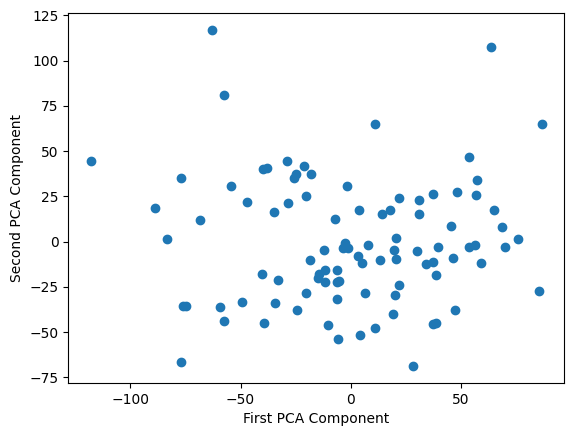

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x2, y2 = pca_vals_2[:,0],pca_vals_2[:, 1]

plt.scatter(x2, y2)
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.show()

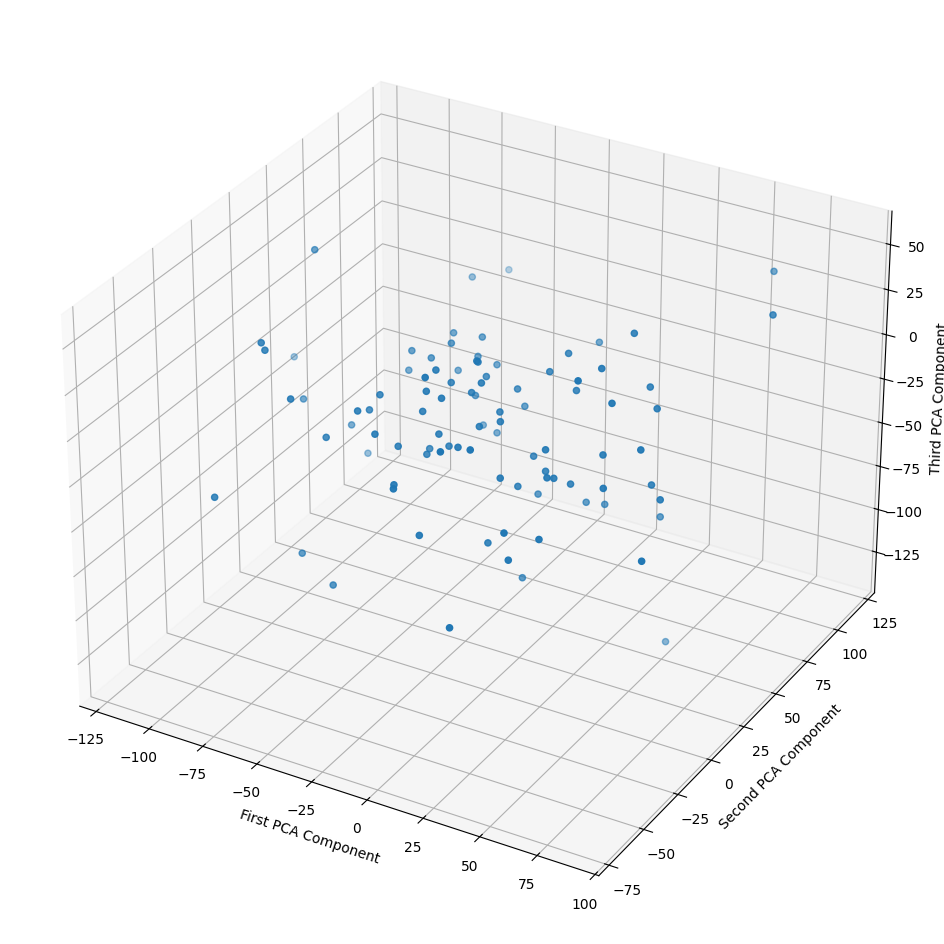

In [41]:
x3, y3, z3 = pca_vals_3[:, 0], pca_vals_3[:, 1], pca_vals_3[:, 2]
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x3, y3, z3)

ax.set_xlabel("First PCA Component")
ax.set_ylabel("Second PCA Component")
ax.set_zlabel("Third PCA Component")

plt.show()

In [ ]:
# ── 8. PREP FOR PCA / CLUSTERING / ARM ───────────────────────────────────────
# This section prepares three separate matrices from the same feature dataframe.

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

feature_cols = [c for c in df.columns if c != 'event_code']
X = df[feature_cols].values
y = df['event_code'].values

# Fill any NaNs (e.g. from missing frontal channels)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize (essential for PCA and clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\nReady for PCA/Clustering: X_scaled shape = {X_scaled.shape}")
print(f"Labels (event codes): {np.unique(y)}")

# -- For ARM: binarize features by median split --
# ARM needs binary/categorical data ("high alpha" vs "low alpha", etc.)
X_binary = (X_imputed > np.median(X_imputed, axis=0)).astype(int)
df_binary = pd.DataFrame(X_binary, columns=feature_cols)
df_binary['event_code'] = y
df_binary.to_csv("eeg_features_binary.csv", index=False)
print("Saved binarized features to eeg_features_binary.csv (for ARM)")

# ── Summary of outputs ────────────────────────────────────────────────────────
print("\n── Outputs ──────────────────────────────────────────────────────")
print("  eeg_features.csv        → scaled feature matrix for PCA + clustering")
print("  eeg_features_binary.csv → binarized features for ARM")
print("  X_scaled                → numpy array ready for sklearn PCA/KMeans")
print("  X_binary / df_binary    → ready for mlxtend Apriori/FP-Growth")

In [9]:
all_features

[{'A4_mean': np.float64(6.668754855377418e-08),
  'A4_var': np.float64(1.694160311732184e-10),
  'A4_skew': np.float64(0.16735686407293093),
  'A4_kurt': np.float64(1.1045868152503138),
  'A4_zcr': np.float64(0.055609756097560976),
  'A4_p2p': np.float64(8.673607290570674e-05),
  'A4_hjorth_act': np.float64(1.694160311732184e-10),
  'A4_hjorth_mob': np.float64(0.13162811526036425),
  'A4_hjorth_cmp': np.float64(1.0474940984235326),
  'A4_bp_delta': np.float64(1.2616105818685212e-10),
  'A4_bp_theta': np.float64(7.781112958291263e-12),
  'A4_bp_alpha': np.float64(1.0436995613837694e-11),
  'A4_bp_beta': np.float64(9.47279881439041e-12),
  'A4_bp_gamma': np.float64(1.598048977828927e-12),
  'A4_bpr_delta': np.float64(0.49387767077838773),
  'A4_bpr_theta': np.float64(0.030460413055610442),
  'A4_bpr_alpha': np.float64(0.040857291130612886),
  'A4_bpr_beta': np.float64(0.037082788313921804),
  'A4_bpr_gamma': np.float64(0.0062558186995468985),
  'A4_ratio_theta_alpha': np.float64(0.070457